In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import warnings

In [ ]:
df = pd.read_csv('/content/cyberpunk_steam_reviews_clean.csv')
df

,language,review_text,created_at,is_recommended,helpful_votes,funny_votes,vote_score,num_comments,is_steam_purchase,is_free,num_games_owned,num_reviews,total_playtime_min,playtime_at_review_min
0,brazilian,[h1] Do lixo ao luxo. [/h1]\n\n[i] Cyberpunk 2...,2025-02-23 20:21:19,True,135,3,0.904349,23,True,False,506,130,8964,8964
1,brazilian,Ainda em dúvida se vale a pena jogar Cyberpunk...,2025-08-03 18:01:43,True,97,11,0.888484,1,True,False,534,6,9865,4919
2,brazilian,[h3] Cyberpunk 2077 é uma experiência de vida....,2024-12-15 05:02:32,True,72,0,0.864477,1,True,False,82,32,4898,4574
3,brazilian,Eu comprei Cyberpunk na pre venda em 2020 e po...,2025-06-16 07:33:42,True,53,2,0.844979,0,True,False,336,42,15237,12634
4,brazilian,Cyberpunk 2077 é um jogo excepcional que se de...,2024-11-28 00:32:22,True,67,0,0.837374,8,True,False,0,4,16573,6887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41404,english,Very Nice,2025-07-21 05:52:16,True,0,0,0.500000,0,True,False,0,1,3714,3594
41405,english,great,2025-07-21 05:10:11,True,0,0,0.500000,0,True,False,0,1,7341,6999
41406,english,10/10,2025-07-21 02:36:18,True,0,0,0.500000,0,True,False,0,1,4821,1945
41407,english,"HAAAANK!\n\nHANK, DON'T ABBREVIATE CYBERPUNK.\...",2025-07-21 00:58:47,True,0,0,0.500000,0,True,False,230,14,10968,10391


In [ ]:
print("Numero de textos nulos 'review_text':", df['review_text'].isnull().sum())
print("Numero de textos vazios em'review_text':", (df['review_text'].astype(str).str.strip() == '').sum())

Numero de textos nulos 'review_text': 0
Numero de textos vazios em'review_text': 4


Alguns comentário vázios mesmo após o tratamento inicial dos dados, vamos remover esses comentários vazios pois não fazem sentido para nossa análise.


In [ ]:
df.drop(df[df['review_text'].astype(str).str.strip() == ''].index, inplace=True)
df

,language,review_text,created_at,is_recommended,helpful_votes,funny_votes,vote_score,num_comments,is_steam_purchase,is_free,num_games_owned,num_reviews,total_playtime_min,playtime_at_review_min
0,brazilian,[h1] Do lixo ao luxo. [/h1]\n\n[i] Cyberpunk 2...,2025-02-23 20:21:19,True,135,3,0.904349,23,True,False,506,130,8964,8964
1,brazilian,Ainda em dúvida se vale a pena jogar Cyberpunk...,2025-08-03 18:01:43,True,97,11,0.888484,1,True,False,534,6,9865,4919
2,brazilian,[h3] Cyberpunk 2077 é uma experiência de vida....,2024-12-15 05:02:32,True,72,0,0.864477,1,True,False,82,32,4898,4574
3,brazilian,Eu comprei Cyberpunk na pre venda em 2020 e po...,2025-06-16 07:33:42,True,53,2,0.844979,0,True,False,336,42,15237,12634
4,brazilian,Cyberpunk 2077 é um jogo excepcional que se de...,2024-11-28 00:32:22,True,67,0,0.837374,8,True,False,0,4,16573,6887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41404,english,Very Nice,2025-07-21 05:52:16,True,0,0,0.500000,0,True,False,0,1,3714,3594
41405,english,great,2025-07-21 05:10:11,True,0,0,0.500000,0,True,False,0,1,7341,6999
41406,english,10/10,2025-07-21 02:36:18,True,0,0,0.500000,0,True,False,0,1,4821,1945
41407,english,"HAAAANK!\n\nHANK, DON'T ABBREVIATE CYBERPUNK.\...",2025-07-21 00:58:47,True,0,0,0.500000,0,True,False,230,14,10968,10391


Passando olho rapidamente pelo dataset notamos que alguns comentários tinha linguas não necessariamente EN e PT, então decidimos realizar um filtro robusto de de linguagem, desconfiando que a coluna language não necessariamente era a coluna do comentário e sim a language dita pelo usuário na STEAM.

vamos fazer essa análise então, antes de pré processar os comentários.

In [ ]:
!pip install langdetect
from langdetect import detect_langs, DetectorFactory
from langdetect import detect
from langdetect import LangDetectException

DetectorFactory.seed = 0

def detect_lang(text):
    try:
        langs = detect_langs(text)
        langs = [l for l in langs if l.lang in ('en', 'pt')]
        if not langs:
            return 'unknown'
        return max(langs, key=lambda x: x.prob).lang
    except LangDetectException:
        return 'unknown'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 11.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=db00f46f4ad0ba3fe1e098ffbb762fec36d7c6a8bfd6ef50f6e4818a3d3f6211
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
df['detected_lang'] = df['review_text'].apply(detect_lang)
df['detected_lang'].value_counts()

,count
detected_lang,
en,32120
pt,5392
unknown,3893


O detect language ele tem alguns problemas para definir a linguagem quando o comentário é muito pequeno ou apresentam números, decidimos deixar esses comentários desconhecimentos, pois por exemplo: great é um comentário relevante e foi tido como uma linguagem desconhecida.

Pré-Processamento dos comentários: normalização e limpeza

In [ ]:
def clean_basic_review(texto: str) -> str:
    if not isinstance(texto, str) or len(texto.strip()) == 0:
        return ""

    # Remove URLs
    texto = re.sub(r'https?://\S+|www\.\S+', '', texto)

    # Remove tags BBCode e HTML
    texto = re.sub(r'\[.*?\]|<.*?>', '', texto)

    # Remove emojis e símbolos especiais
    texto = re.sub(r'[^\w\sáéíóúãõâêîôûçÁÉÍÓÚÃÕÂÊÎÔÛÇ.,!?;:\'\"-/%()]+', ' ', texto)

    # Reduz repetições exageradas (looool → lool)
    texto = re.sub(r'(.)\1{2,}', r'\1\1', texto)

    # Normaliza espaços múltiplos
    texto = re.sub(r'\s+', ' ', texto).strip()

    # Lowercase
    texto = texto.lower()

    return texto


In [ ]:
df['review_text'] = df['review_text'].apply(clean_basic_review)
df

,language,review_text,created_at,is_recommended,helpful_votes,funny_votes,vote_score,num_comments,is_steam_purchase,is_free,num_games_owned,num_reviews,total_playtime_min,playtime_at_review_min,detected_lang
0,brazilian,do lixo ao luxo. cyberpunk 2077 é um jogo de r...,2025-02-23 20:21:19,True,135,3,0.904349,23,True,False,506,130,8964,8964,pt
1,brazilian,ainda em dúvida se vale a pena jogar cyberpunk...,2025-08-03 18:01:43,True,97,11,0.888484,1,True,False,534,6,9865,4919,pt
2,brazilian,cyberpunk 2077 é uma experiência de vida. o me...,2024-12-15 05:02:32,True,72,0,0.864477,1,True,False,82,32,4898,4574,pt
3,brazilian,eu comprei cyberpunk na pre venda em 2020 e po...,2025-06-16 07:33:42,True,53,2,0.844979,0,True,False,336,42,15237,12634,pt
4,brazilian,cyberpunk 2077 é um jogo excepcional que se de...,2024-11-28 00:32:22,True,67,0,0.837374,8,True,False,0,4,16573,6887,pt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41404,english,very nice,2025-07-21 05:52:16,True,0,0,0.500000,0,True,False,0,1,3714,3594,en
41405,english,great,2025-07-21 05:10:11,True,0,0,0.500000,0,True,False,0,1,7341,6999,unknown
41406,english,10/10,2025-07-21 02:36:18,True,0,0,0.500000,0,True,False,0,1,4821,1945,unknown
41407,english,"haank! hank, don't abbreviate cyberpunk. haank!",2025-07-21 00:58:47,True,0,0,0.500000,0,True,False,230,14,10968,10391,en


In [ ]:
print("Numero de textos nulos 'review_text':", df['review_text'].isnull().sum())
print("Numero de textos vazios em'review_text':", (df['review_text'].astype(str).str.strip() == '').sum())

Numero de textos nulos 'review_text': 0
Numero de textos vazios em'review_text': 41


Após realizar a limpeza dos dados, notamos que temos mais comentários vazio, provavalmente por serem só emojis, tags HTML, links ou até mesmo imagem ASCII

Vamos remover esses comentários.

In [ ]:
df.drop(df[df['review_text'].astype(str).str.strip() == ''].index, inplace=True)
df


,language,review_text,created_at,is_recommended,helpful_votes,funny_votes,vote_score,num_comments,is_steam_purchase,is_free,num_games_owned,num_reviews,total_playtime_min,playtime_at_review_min,detected_lang
0,brazilian,do lixo ao luxo. cyberpunk 2077 é um jogo de r...,2025-02-23 20:21:19,True,135,3,0.904349,23,True,False,506,130,8964,8964,pt
1,brazilian,ainda em dúvida se vale a pena jogar cyberpunk...,2025-08-03 18:01:43,True,97,11,0.888484,1,True,False,534,6,9865,4919,pt
2,brazilian,cyberpunk 2077 é uma experiência de vida. o me...,2024-12-15 05:02:32,True,72,0,0.864477,1,True,False,82,32,4898,4574,pt
3,brazilian,eu comprei cyberpunk na pre venda em 2020 e po...,2025-06-16 07:33:42,True,53,2,0.844979,0,True,False,336,42,15237,12634,pt
4,brazilian,cyberpunk 2077 é um jogo excepcional que se de...,2024-11-28 00:32:22,True,67,0,0.837374,8,True,False,0,4,16573,6887,pt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41404,english,very nice,2025-07-21 05:52:16,True,0,0,0.500000,0,True,False,0,1,3714,3594,en
41405,english,great,2025-07-21 05:10:11,True,0,0,0.500000,0,True,False,0,1,7341,6999,unknown
41406,english,10/10,2025-07-21 02:36:18,True,0,0,0.500000,0,True,False,0,1,4821,1945,unknown
41407,english,"haank! hank, don't abbreviate cyberpunk. haank!",2025-07-21 00:58:47,True,0,0,0.500000,0,True,False,230,14,10968,10391,en


# ANALISES UNIVARIADAS

Realizando uma criação de feature de análise para ver as estatisticas básicas dos comentários.



In [ ]:

df['word_count'] = df['review_text'].fillna('').str.split().str.len()
df['char_count'] = df['review_text'].fillna('').str.len()
df['avg_word_length'] = df['char_count'] / df['word_count'].replace(0, 1)

text_stats = df[['word_count', 'char_count', 'avg_word_length']].describe()
print(text_stats)

         word_count    char_count  avg_word_length
count  41364.000000  41364.000000     41364.000000
mean      49.511822    272.209482         5.397178
std      104.064936    585.620552         1.695184
min        1.000000      1.000000         1.000000
25%        7.000000     37.000000         4.916667
50%       17.000000     89.000000         5.333333
75%       46.000000    246.000000         5.750000
max     1507.000000   7996.000000       273.000000


In [ ]:
df.loc[df['avg_word_length'] > 20, 'review_text'].head()

,review_text
14083,javascript:dselectnoop();
26217,ilovethisgameilovethisgameilovethisgameiloveth...
26866,有史以来体验过最好的剧情投入感和故事的深刻程度
28786,yesyesyesyesyesyesyesyesyesyesyesyesyesyesyesy...
29749,單單是製作組負責任的態度就足以讓其他廠商學習


In [ ]:
df['review_length_category'] = pd.cut(
    df['word_count'],
    bins=[0, 5, 20, 100, 500, float('inf')],
    labels=['Muito Curta (<5)', 'Curta (5-20)', 'Média (20-100)',
            'Longa (100-500)', 'Muito Longa (500+)']
)

print("\n📏 DISTRIBUIÇÃO POR TAMANHO:")
print(df['review_length_category'].value_counts().sort_index())


📏 DISTRIBUIÇÃO POR TAMANHO:
review_length_category
Muito Curta (<5)       8283
Curta (5-20)          14846
Média (20-100)        13319
Longa (100-500)        4479
Muito Longa (500+)      437
Name: count, dtype: int64


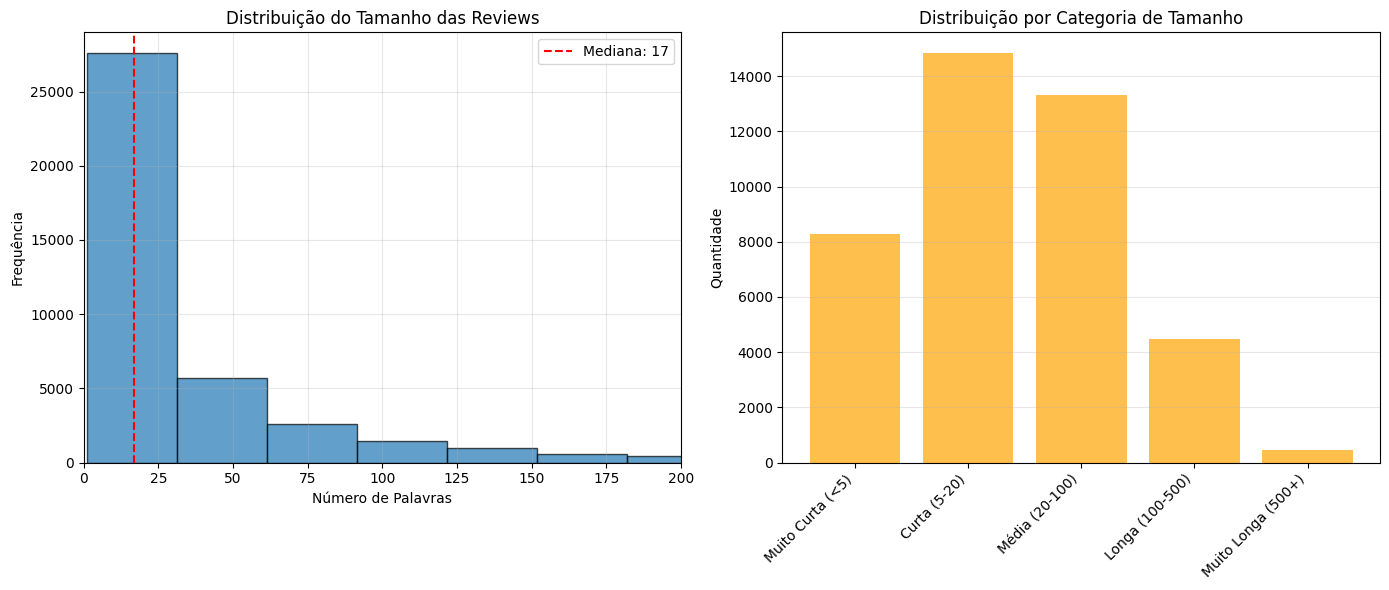

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1️⃣ Distribuição de tamanho do comentário
axes[0].hist(df['word_count'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['word_count'].median(), color='red', linestyle='--',
                label=f'Mediana: {df["word_count"].median():.0f}')
axes[0].set_xlabel('Número de Palavras')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição do Tamanho das Reviews')
axes[0].legend()
axes[0].set_xlim(0, 200)
axes[0].grid(alpha=0.3)

# 2️⃣ Categorias de tamanho
size_counts = df['review_length_category'].value_counts().sort_index()
axes[1].bar(range(len(size_counts)), size_counts.values, alpha=0.7, color='orange')
axes[1].set_xticks(range(len(size_counts)))
axes[1].set_xticklabels(size_counts.index, rotation=45, ha='right')
axes[1].set_ylabel('Quantidade')
axes[1].set_title('Distribuição por Categoria de Tamanho')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
import plotly.express as px
fig = px.histogram(df, x="word_count")
fig.show()

In [ ]:
import string
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_pt = set(stopwords.words('portuguese'))
stop_en = set(stopwords.words('english'))

def clean_for_nlp(texto: str, lang: str = 'english') -> str:
    if not isinstance(texto, str) or len(texto.strip()) == 0:
        return ""

    texto = texto.lower()

    texto = texto.translate(str.maketrans('', '', string.punctuation.replace('/', '')))
    texto = texto.replace('/', ' ')

    if lang.lower().startswith('en'):
        stoplist = stop_en
    elif lang.lower().startswith(('br')):
        stoplist = stop_pt
    else:
        stoplist = set()
    palavras = [
        p for p in texto.split()
        if p not in stoplist and len(p) >= 2
    ]

    texto = ' '.join(palavras)
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
df['clean_text'] = df.apply(
    lambda row: clean_for_nlp(row['review_text'], lang=row['language']),
    axis=1
)


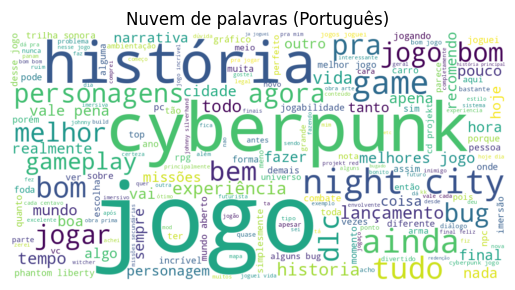

In [ ]:
from wordcloud import WordCloud

text_pt = ' '.join(df[df['language'].str.startswith('br')]['clean_text'])
wordcloud_pt = WordCloud(width=1000, height=500, background_color='white').generate(text_pt)

plt.imshow(wordcloud_pt, interpolation='bilinear')
plt.axis('off')
plt.title("Nuvem de palavras (Português)")
plt.show()


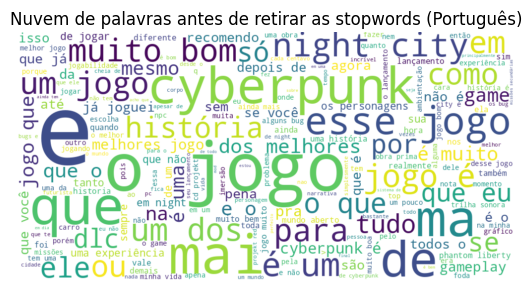

In [ ]:
text_pt = ' '.join(df[df['language'].str.startswith('br')]['review_text'])
wordcloud_pt = WordCloud(width=1000, height=500, background_color='white').generate(text_pt)

plt.imshow(wordcloud_pt, interpolation='bilinear')
plt.axis('off')
plt.title("Nuvem de palavras antes de retirar as stopwords (Português)")
plt.show()


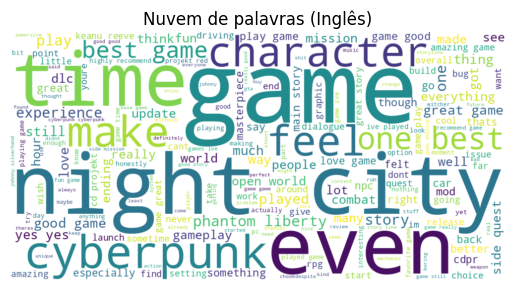

In [ ]:
text_en = ' '.join(df[df['language'].str.startswith('en')]['clean_text'])
wordcloud_pt = WordCloud(width=1000, height=500, background_color='white').generate(text_en)

plt.imshow(wordcloud_pt, interpolation='bilinear')
plt.axis('off')
plt.title("Nuvem de palavras (Inglês)")
plt.show()

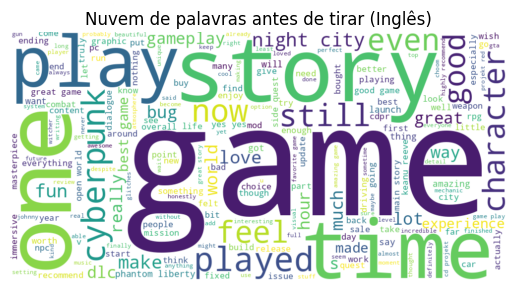

In [ ]:
text_en = ' '.join(df[df['language'].str.startswith('en')]['review_text'])
wordcloud_pt = WordCloud(width=1000, height=500, background_color='white').generate(text_en)

plt.imshow(wordcloud_pt, interpolation='bilinear')
plt.axis('off')
plt.title("Nuvem de palavras antes de tirar (Inglês)")
plt.show()

ANALISANDO AGORA OUTRAS COLUNAS PARA OUTRAS ANÁLISES UNIVARIADAS

In [ ]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

In [ ]:
df['total_playtime_hours'] = df['total_playtime_min'] / 60
df['playtime_at_review_hours'] = df['playtime_at_review_min'] / 60
df


,language,review_text,created_at,is_recommended,helpful_votes,funny_votes,vote_score,num_comments,is_steam_purchase,is_free,...,total_playtime_min,playtime_at_review_min,detected_lang,word_count,char_count,avg_word_length,review_length_category,clean_text,total_playtime_hours,playtime_at_review_hours
0,brazilian,do lixo ao luxo. cyberpunk 2077 é um jogo de r...,2025-02-23 20:21:19,True,135,3,0.904349,23,True,False,...,8964,8964,pt,1182,6983,5.907783,Muito Longa (500+),lixo luxo cyberpunk 2077 jogo rpg ação primeir...,149.400000,149.400000
1,brazilian,ainda em dúvida se vale a pena jogar cyberpunk...,2025-08-03 18:01:43,True,97,11,0.888484,1,True,False,...,9865,4919,pt,223,1235,5.538117,Longa (100-500),ainda dúvida vale pena jogar cyberpunk 2077 ho...,164.416667,81.983333
2,brazilian,cyberpunk 2077 é uma experiência de vida. o me...,2024-12-15 05:02:32,True,72,0,0.864477,1,True,False,...,4898,4574,pt,287,1669,5.815331,Longa (100-500),cyberpunk 2077 experiência vida melhor jogo jo...,81.633333,76.233333
3,brazilian,eu comprei cyberpunk na pre venda em 2020 e po...,2025-06-16 07:33:42,True,53,2,0.844979,0,True,False,...,15237,12634,pt,138,801,5.804348,Longa (100-500),comprei cyberpunk pre venda 2020 posso falar t...,253.950000,210.566667
4,brazilian,cyberpunk 2077 é um jogo excepcional que se de...,2024-11-28 00:32:22,True,67,0,0.837374,8,True,False,...,16573,6887,pt,177,1167,6.593220,Longa (100-500),cyberpunk 2077 jogo excepcional destaca divers...,276.216667,114.783333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41404,english,very nice,2025-07-21 05:52:16,True,0,0,0.500000,0,True,False,...,3714,3594,en,2,9,4.500000,Muito Curta (<5),nice,61.900000,59.900000
41405,english,great,2025-07-21 05:10:11,True,0,0,0.500000,0,True,False,...,7341,6999,unknown,1,5,5.000000,Muito Curta (<5),great,122.350000,116.650000
41406,english,10/10,2025-07-21 02:36:18,True,0,0,0.500000,0,True,False,...,4821,1945,unknown,1,5,5.000000,Muito Curta (<5),10 10,80.350000,32.416667
41407,english,"haank! hank, don't abbreviate cyberpunk. haank!",2025-07-21 00:58:47,True,0,0,0.500000,0,True,False,...,10968,10391,en,6,47,7.833333,Curta (5-20),haank hank dont abbreviate cyberpunk haank,182.800000,173.183333


In [ ]:
print("OUTLIERS EM TEMPO DE JOGO:")

outliers_playtime, lower, upper = detect_outliers_iqr(df, 'total_playtime_hours')
print(f"Total de outliers: {len(outliers_playtime)} ({len(outliers_playtime)/len(df)*100:.2f}%)")
print(f"Limite inferior: {lower:.0f} h ({lower}h)")
print(f"Limite superior: {upper:.0f} h ({upper}h)")

OUTLIERS EM TEMPO DE JOGO:
Total de outliers: 2970 (7.18%)
Limite inferior: -123 h (-123.02499999999999h)
Limite superior: 345 h (345.17499999999995h)


In [ ]:
print("OUTLIERS EM TEMPO DE JOGO ANTES DE FAZER OS COMENTÁRIOS:")

outliers_playtime, lower, upper = detect_outliers_iqr(df, 'playtime_at_review_hours')
print(f"Total de outliers: {len(outliers_playtime)} ({len(outliers_playtime)/len(df)*100:.2f}%)")
print(f"Limite inferior: {lower:.0f} h ({lower}h)")
print(f"Limite superior: {upper:.0f} h ({upper}h)")

OUTLIERS EM TEMPO DE JOGO ANTES DE FAZER OS COMENTÁRIOS:
Total de outliers: 2951 (7.13%)
Limite inferior: -121 h (-121.02291666666665h)
Limite superior: 272 h (272.19374999999997h)


In [ ]:
print("OUTLIERS EM NÚMERO DE REVIEWS (USUÁRIO):")

outliers_reviews, lower_r, upper_r = detect_outliers_iqr(df, 'num_reviews')
print(f"Total de outliers: {len(outliers_reviews)} ({len(outliers_reviews)/len(df)*100:.2f}%)")
print(f"Usuários com > {upper_r:.0f} reviews: {(df['num_reviews'] > upper_r).sum()}")

OUTLIERS EM NÚMERO DE REVIEWS (USUÁRIO):
Total de outliers: 3730 (9.02%)
Usuários com > 36 reviews: 3730


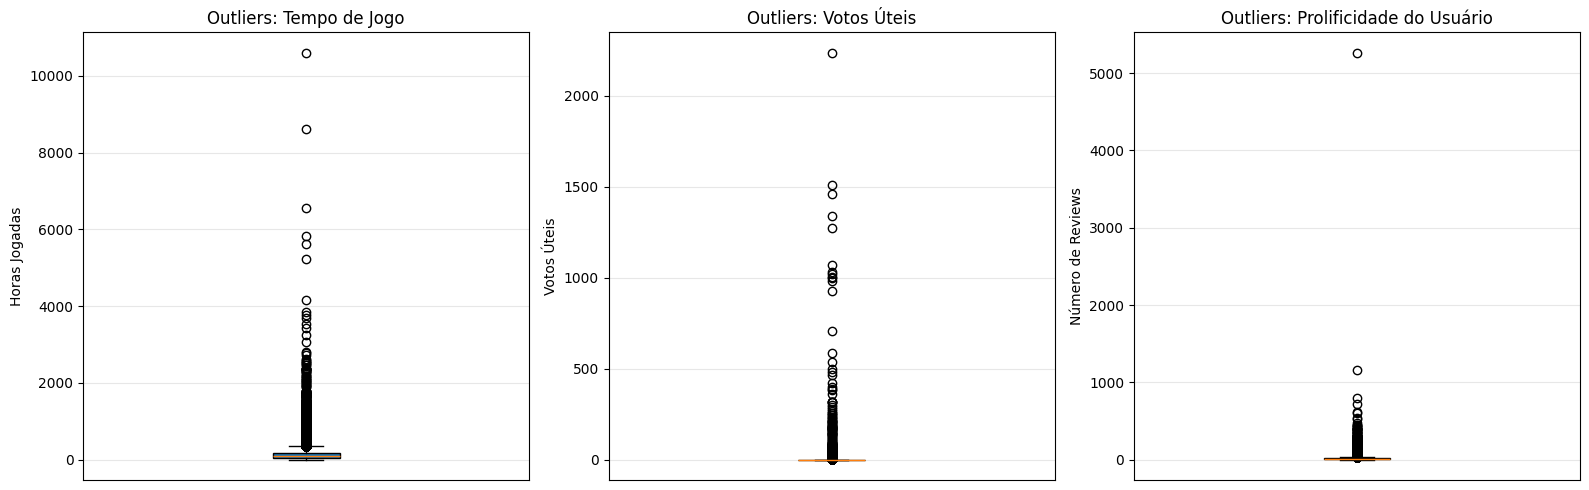

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Boxplot: Tempo de jogo
axes[0].boxplot([df['total_playtime_min']/60], vert=True, patch_artist=True)
axes[0].set_ylabel('Horas Jogadas')
axes[0].set_title('Outliers: Tempo de Jogo')
axes[0].set_xticks([])
axes[0].grid(axis='y', alpha=0.3)

# Boxplot: Helpful votes
axes[1].boxplot([df['helpful_votes']], vert=True, patch_artist=True)
axes[1].set_ylabel('Votos Úteis')
axes[1].set_title('Outliers: Votos Úteis')
axes[1].set_xticks([])
axes[1].grid(axis='y', alpha=0.3)

# Boxplot: Num reviews por usuário
axes[2].boxplot([df['num_reviews']], vert=True, patch_artist=True)
axes[2].set_ylabel('Número de Reviews')
axes[2].set_title('Outliers: Prolificidade do Usuário')
axes[2].set_xticks([])
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

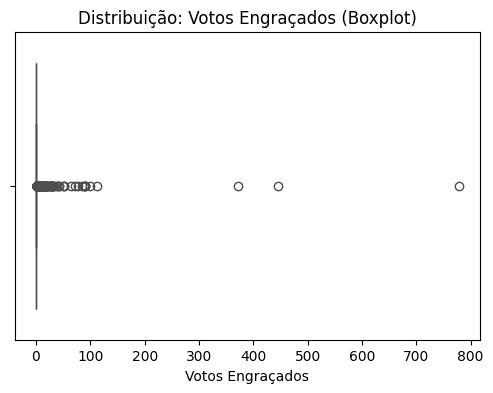

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['funny_votes'], color='#f39c12')
plt.xlabel('Votos Engraçados')
plt.title('Distribuição: Votos Engraçados (Boxplot)')
plt.show()

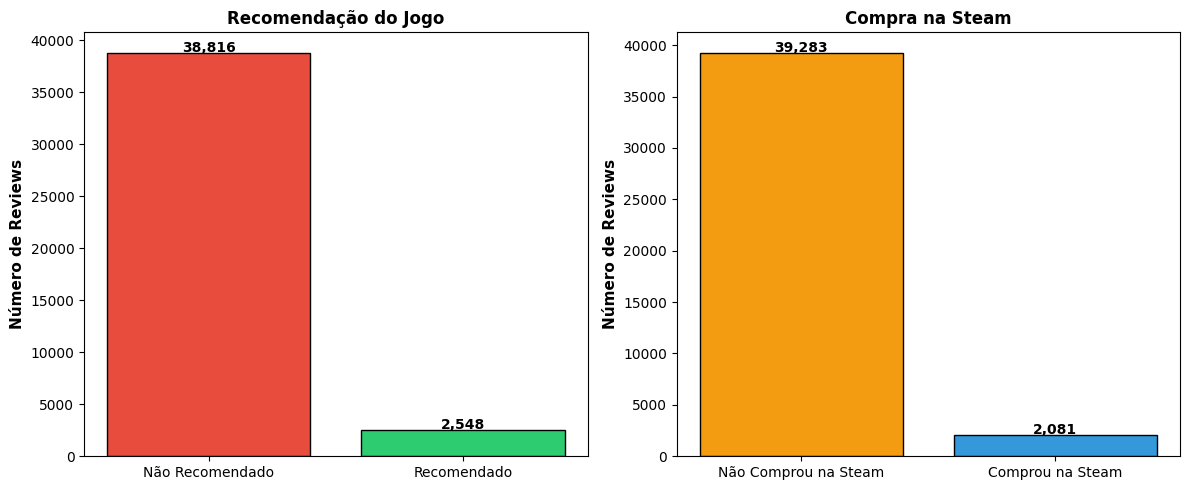

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

recommend_counts = df['is_recommended'].value_counts()
axes[0].bar(['Não Recomendado', 'Recomendado'], recommend_counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Recomendação do Jogo', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de Reviews', fontsize=11, fontweight='bold')

for i, count in enumerate(recommend_counts.values):
    axes[0].text(i, count + 50, f'{count:,}', ha='center', fontweight='bold')

steam_counts = df['is_steam_purchase'].value_counts()
axes[1].bar(['Não Comprou na Steam', 'Comprou na Steam'], steam_counts.values,
            color=['#f39c12', '#3498db'], edgecolor='black')
axes[1].set_title('Compra na Steam', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Número de Reviews', fontsize=11, fontweight='bold')

for i, count in enumerate(steam_counts.values):
    axes[1].text(i, count + 50, f'{count:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


ANÁLISE TEMPORAL DOS COMENTÁRIOS

In [ ]:
from datetime import datetime
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')

df['year'] = df['created_at'].dt.year
df['month'] = df['created_at'].dt.month
df['year_month'] = df['created_at'].dt.to_period('M')
df['quarter'] = df['created_at'].dt.to_period('Q')
df['day_of_week'] = df['created_at'].dt.day_name()
df['hour'] = df['created_at'].dt.hour

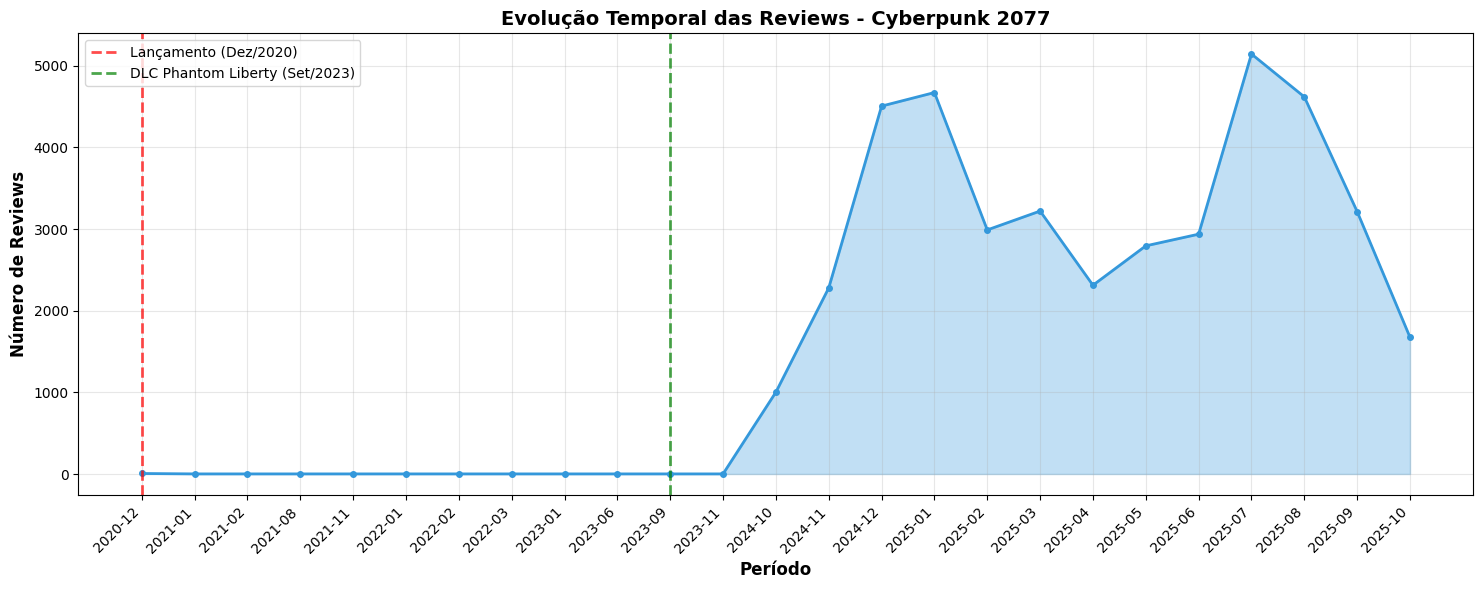

In [ ]:
fig, ax1 = plt.subplots(figsize=(18, 6))

reviews_per_month = df.groupby('year_month').size()

ax1.plot(reviews_per_month.index.astype(str), reviews_per_month.values,
         linewidth=2, marker='o', markersize=4, color='#3498db')
ax1.fill_between(range(len(reviews_per_month)), reviews_per_month.values,
                 alpha=0.3, color='#3498db')

# Eventos importantes
launch_date = pd.Period('2020-12', 'M')
dlc_date = pd.Period('2023-09', 'M')

if launch_date in reviews_per_month.index:
    launch_idx = list(reviews_per_month.index).index(launch_date)
    ax1.axvline(launch_idx, color='red', linestyle='--', linewidth=2, alpha=0.7,
                label='Lançamento (Dez/2020)')
if dlc_date in reviews_per_month.index:
    dlc_idx = list(reviews_per_month.index).index(dlc_date)
    ax1.axvline(dlc_idx, color='green', linestyle='--', linewidth=2, alpha=0.7,
                label='DLC Phantom Liberty (Set/2023)')

ax1.set_xlabel('Período', fontsize=12, fontweight='bold')
ax1.set_ylabel('Número de Reviews', fontsize=12, fontweight='bold')
ax1.set_title('Evolução Temporal das Reviews - Cyberpunk 2077', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Rotacionar labels do eixo x
step = max(1, len(reviews_per_month) // 20)
ax1.set_xticks(range(0, len(reviews_per_month), step))
ax1.set_xticklabels([str(x) for x in reviews_per_month.index[::step]], rotation=45, ha='right')

plt.show()

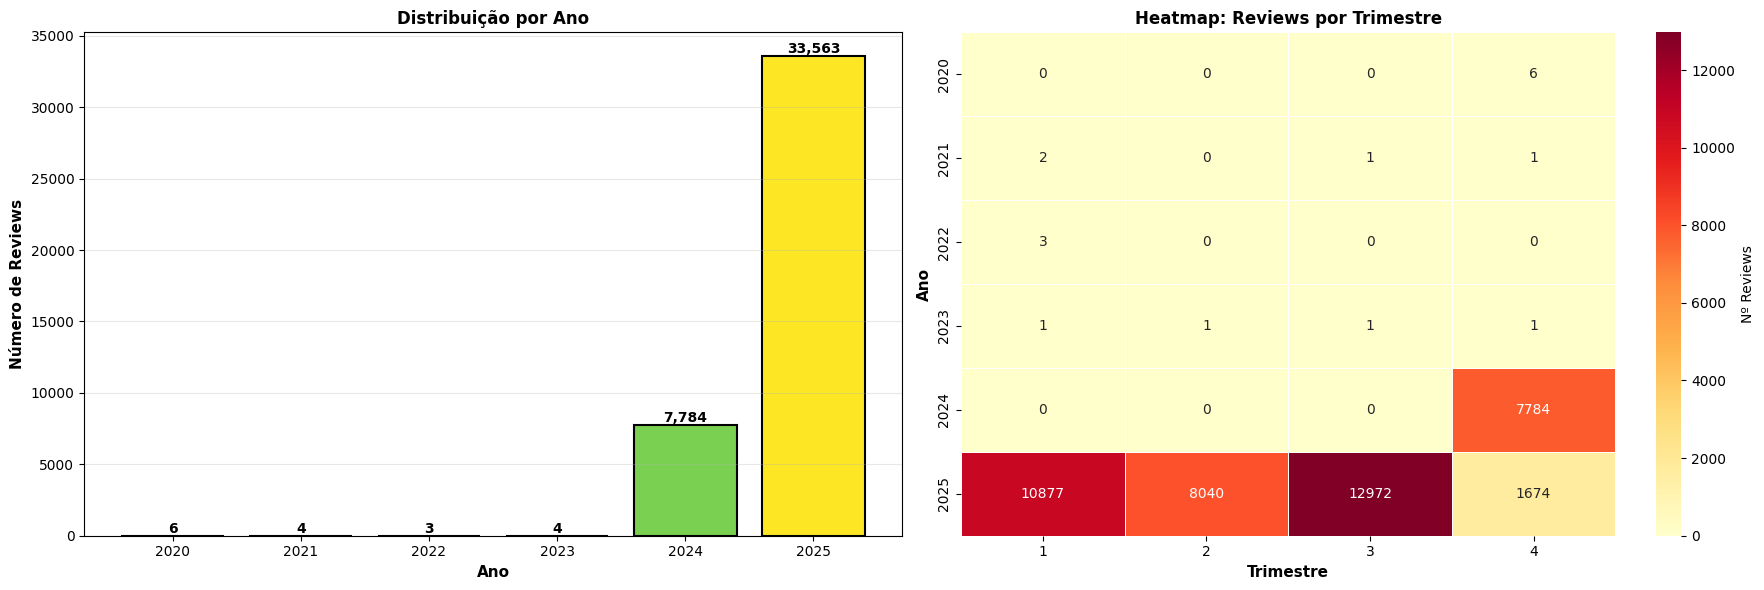

In [ ]:
import seaborn as sns
import numpy as np

fig, (ax2, ax3) = plt.subplots(1, 2, figsize=(18, 6))

# -------- Distribuição por Ano --------
year_counts = df['year'].value_counts().sort_index()
colors_year = plt.cm.viridis(np.linspace(0, 1, len(year_counts)))

bars = ax2.bar(year_counts.index.astype(str), year_counts.values,
               color=colors_year, edgecolor='black', linewidth=1.5)

for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontweight='bold')

ax2.set_xlabel('Ano', fontsize=11, fontweight='bold')
ax2.set_ylabel('Número de Reviews', fontsize=11, fontweight='bold')
ax2.set_title('Distribuição por Ano', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# -------- Distribuição por Trimestre (heatmap) --------
quarter_pivot = df.groupby(['year', df['created_at'].dt.quarter]).size().unstack(fill_value=0)

sns.heatmap(quarter_pivot, annot=True, fmt='d', cmap='YlOrRd',
            cbar_kws={'label': 'Nº Reviews'}, ax=ax3, linewidths=0.5)
ax3.set_xlabel('Trimestre', fontsize=11, fontweight='bold')
ax3.set_ylabel('Ano', fontsize=11, fontweight='bold')
ax3.set_title('Heatmap: Reviews por Trimestre', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


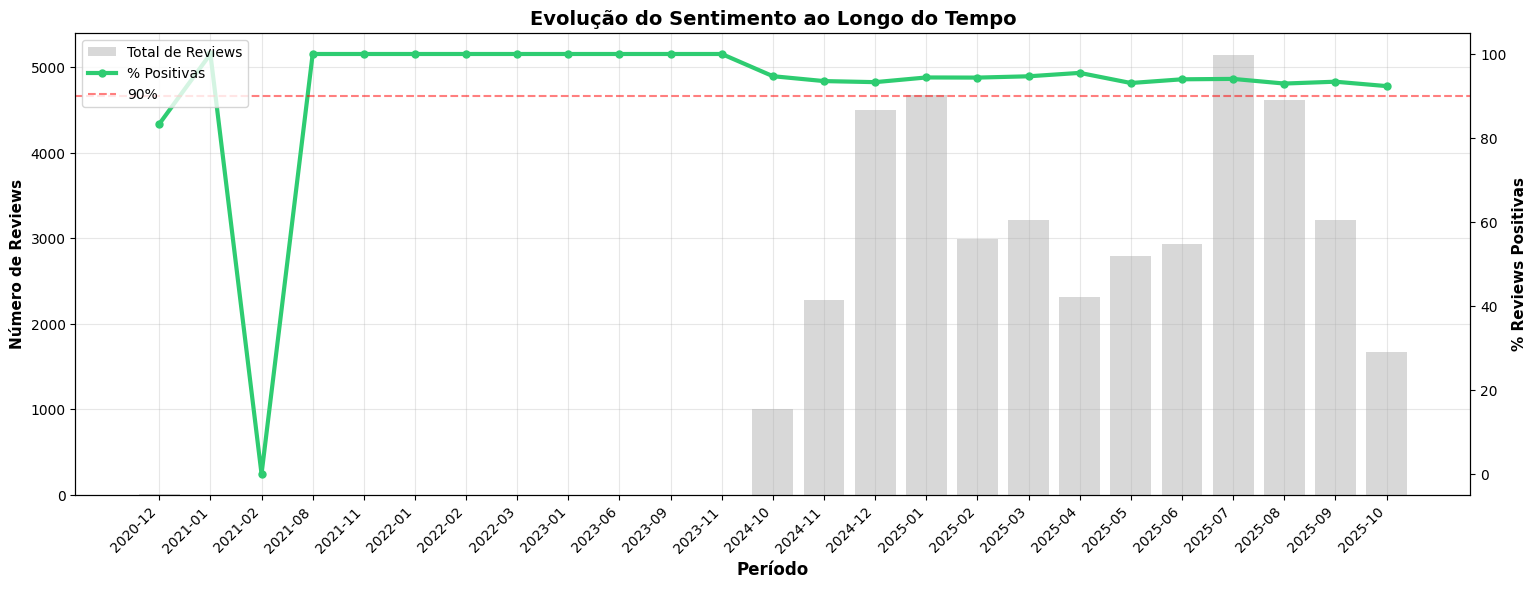

In [ ]:
fig, ax4 = plt.subplots(figsize=(18, 6))

sentiment_by_month = df.groupby('year_month').agg({
    'is_recommended': ['sum', 'count']
})
sentiment_by_month.columns = ['positive', 'total']
sentiment_by_month['pct_positive'] = (sentiment_by_month['positive'] / sentiment_by_month['total'] * 100)

ax4_twin = ax4.twinx()

# Barras: total de reviews
ax4.bar(range(len(sentiment_by_month)), sentiment_by_month['total'], alpha=0.3, color='gray', label='Total de Reviews')

# Linha: % positivas
ax4_twin.plot(range(len(sentiment_by_month)), sentiment_by_month['pct_positive'],
              color='#2ecc71', linewidth=3, marker='o', markersize=5, label='% Positivas')
ax4_twin.axhline(y=90, color='red', linestyle='--', alpha=0.5, label='90%')

ax4.set_xlabel('Período', fontsize=12, fontweight='bold')
ax4.set_ylabel('Número de Reviews', fontsize=11, fontweight='bold')
ax4_twin.set_ylabel('% Reviews Positivas', fontsize=11, fontweight='bold')
ax4.set_title('Evolução do Sentimento ao Longo do Tempo', fontsize=14, fontweight='bold')

lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4_twin.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

step = max(1, len(sentiment_by_month) // 20)
ax4.set_xticks(range(0, len(sentiment_by_month), step))
ax4.set_xticklabels([str(x) for x in sentiment_by_month.index[::step]], rotation=45, ha='right')
ax4.grid(True, alpha=0.3)

plt.show()


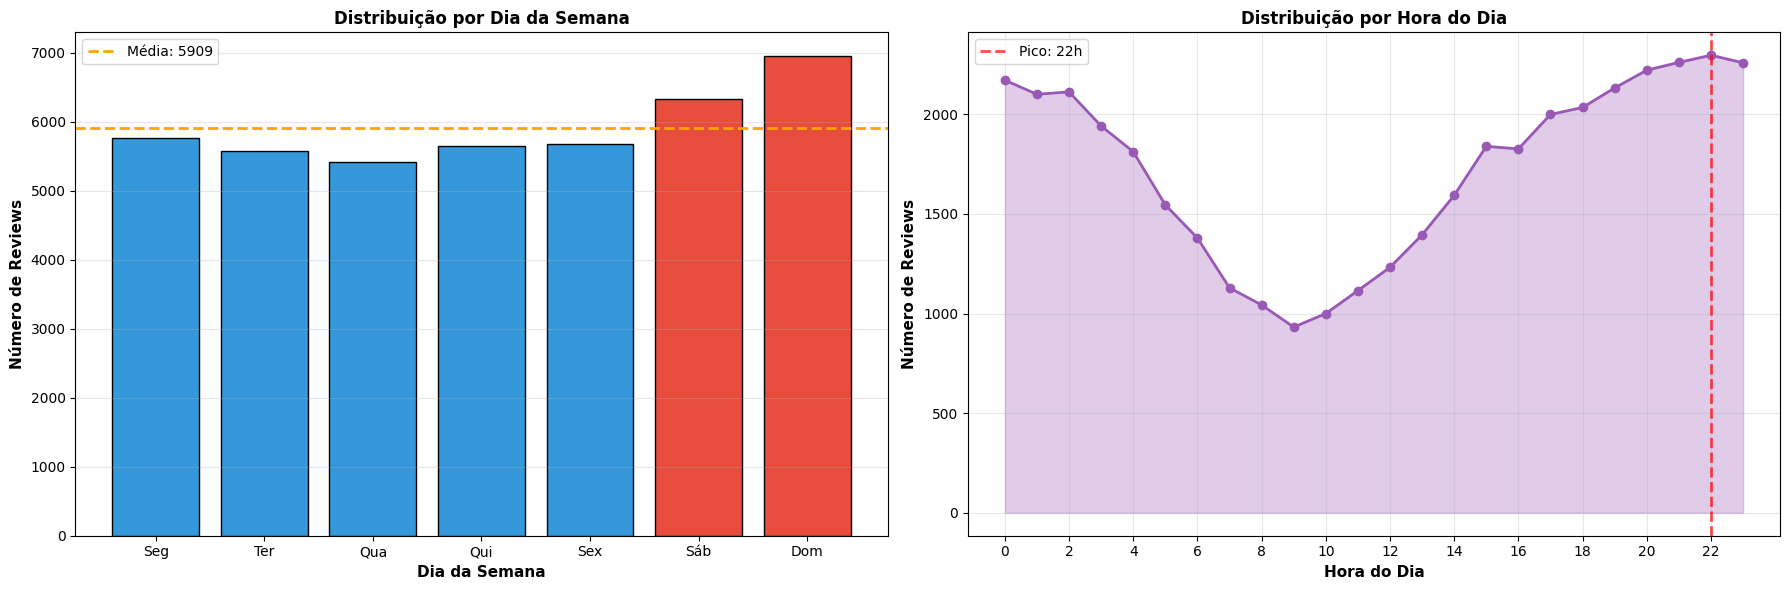

In [ ]:
fig, (ax5, ax6) = plt.subplots(1, 2, figsize=(18, 6))

# -------- Distribuição por Dia da Semana --------
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_abbr = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']

day_counts = df['day_of_week'].value_counts()
day_counts = day_counts.reindex(day_order)

colors_day = ['#e74c3c' if day in ['Saturday', 'Sunday'] else '#3498db' for day in day_order]

ax5.bar(day_abbr, day_counts.values, color=colors_day, edgecolor='black', linewidth=1)
ax5.set_xlabel('Dia da Semana', fontsize=11, fontweight='bold')
ax5.set_ylabel('Número de Reviews', fontsize=11, fontweight='bold')
ax5.set_title('Distribuição por Dia da Semana', fontsize=12, fontweight='bold')
ax5.grid(axis='y', alpha=0.3)

mean_line = day_counts.mean()
ax5.axhline(y=mean_line, color='orange', linestyle='--', linewidth=2, label=f'Média: {mean_line:.0f}')
ax5.legend()

# -------- Distribuição por Hora do Dia --------
hour_counts = df['hour'].value_counts().sort_index()

ax6.plot(hour_counts.index, hour_counts.values, marker='o', linewidth=2, markersize=6, color='#9b59b6')
ax6.fill_between(hour_counts.index, hour_counts.values, alpha=0.3, color='#9b59b6')

peak_hour = hour_counts.idxmax()
ax6.axvline(x=peak_hour, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Pico: {peak_hour}h')

ax6.set_xlabel('Hora do Dia', fontsize=11, fontweight='bold')
ax6.set_ylabel('Número de Reviews', fontsize=11, fontweight='bold')
ax6.set_title('Distribuição por Hora do Dia', fontsize=12, fontweight='bold')
ax6.set_xticks(range(0, 24, 2))
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
